# Power Outage Forecasting
This notebook is a demo for how to load, process, train on, and produce prediction files with the provided dataset.
You should not be confined by this notebook, but highly encouraged to produce your own pipeline or models based on what you learned from the course.

The format of submission files, however, is VERY strict. Student have to follow the provided tempaltes and the submitted files must pass the sanity tests in the last section.

Note the test files loaded in this notebook contain random noise. They only serve the purpose to dmostrate how evalution will be done. The actual test file has been hidden.

It is encouraged to run the starter notebook in Google Colab for easy of debug and implementation. You could also use your local Python notebook.
There is a chance that you run into out of memory when running this demo notebook in Colab free tier. In that case, you could either apply for free Google Colab Pro subscription as student and turn on high RAM, or only run one of the three models (all of the SARIMAX models, Seq2seq model for 24h, or Seq2seq model for 48h) included in the notebook.

## Prerequisites & Installation

Before running this demo notebook, ensure you have the required packages installed:

- `xarray` - for reading NetCDF files
- `netCDF4` - backend for xarray
- `numpy` - numerical operations
- `pandas` - data manipulation
- `matplotlib` - visualization
- `torch` - deep learning (PyTorch)
- `statsmodels` - SARIMAX models
- `tqdm` - progress bars
- `scikit-learn` - baseline models (Ridge, Lasso)

In [ ]:
# if you are first time running this notebook on Colab, you might need this:
!pip install netCDF4 scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.7 MB/s eta 0:00:00


In [ ]:
# Check dependencies
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'xarray': 'xarray',
    'netCDF4': 'netCDF4',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
    'statsmodels': 'statsmodels',
    'tqdm': 'tqdm',
    'sklearn': 'sklearn',
}

missing_packages = []
for package_name, import_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"✓ {package_name} is installed")
    except ImportError as e:
        print(f"✗ {package_name} is NOT installed - {str(e)}")
        missing_packages.append(package_name)

if missing_packages:
    print(f"\n⚠️  Missing packages: {', '.join(missing_packages)}")
else:
    print("\n✓ All required packages are installed!")

✓ numpy is installed
✓ pandas is installed
✓ xarray is installed
✓ netCDF4 is installed
✓ matplotlib is installed
✓ torch is installed
✓ statsmodels is installed
✓ tqdm is installed
✓ sklearn is installed

✓ All required packages are installed!


## 1. Configuration & Setup

Define all meta variables and parameters at the start for easy configuration.

In [ ]:
# ============== META VARIABLES ==============
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Data paths
%cd "/content/drive/MyDrive/MLPS_Project/"
current_dir = Path.cwd()
DATA_DIR = current_dir/"data"
RESULTS_DIR = current_dir/"results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.nc")

# The test_24h_demo.nc and test_48h_demo.nc are just demo files, so the outages in those files are just noise
# TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h.nc")
# TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h.nc")
TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h_demo.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

# Model parameters
VALIDATION_SPLIT = 0.2  # Use last 20% of training data for validation

# SARIMAX parameters
SARIMAX_ORDER = (1, 0, 1)  # (p, d, q)

# Seq2Seq parameters
SEQ_LEN = 24       # Lookback window (hours) for the seq2seq model
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
HIDDEN_DIM = 64
NUM_LAYERS = 1

# Set device for PyTorch
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration loaded successfully!")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Device: {DEVICE}")
print(f"Data Directory: {DATA_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1nCCPQzq1weHUJGqnubEvWjxRzknWqlwY/MLPS_Project
Configuration loaded successfully!
Random Seed: 42
Device: cpu
Data Directory: /content/drive/.shortcut-targets-by-id/1nCCPQzq1weHUJGqnubEvWjxRzknWqlwY/MLPS_Project/data
Results Directory: /content/drive/.shortcut-targets-by-id/1nCCPQzq1weHUJGqnubEvWjxRzknWqlwY/MLPS_Project/results


## 2. Data Loading

Load the NetCDF datasets and explore their structure.

In [ ]:
# Load datasets
ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

In [ ]:
# Extract basic information
train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = list(ds_train.location.values)
weather_features = list(ds_train.feature.values) if 'feature' in ds_train.dims else []

print(f"Training Period: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Number of Timestamps: {len(train_timestamps)}")
print(f"Number of Locations: {len(locations)}")
print(f"Locations: {locations}")
print(f"\nWeather Features ({len(weather_features)}): {weather_features}")

# Extract outage data
outage_data = ds_train.out.transpose("timestamp", "location").values.astype(float)
print(f"\nOutage Data Shape: {outage_data.shape} (timestamps x locations)")
print(f"Outage Statistics:")
print(f"  Mean: {np.nanmean(outage_data):.2f}")
print(f"  Std: {np.nanstd(outage_data):.2f}")
print(f"  Min: {np.nanmin(outage_data):.2f}")
print(f"  Max: {np.nanmax(outage_data):.2f}")

Training Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Number of Timestamps: 2161
Number of Locations: 83
Locations: [np.str_('26001'), np.str_('26003'), np.str_('26005'), np.str_('26007'), np.str_('26009'), np.str_('26011'), np.str_('26013'), np.str_('26015'), np.str_('26017'), np.str_('26019'), np.str_('26021'), np.str_('26023'), np.str_('26025'), np.str_('26027'), np.str_('26029'), np.str_('26031'), np.str_('26033'), np.str_('26035'), np.str_('26037'), np.str_('26039'), np.str_('26041'), np.str_('26043'), np.str_('26045'), np.str_('26047'), np.str_('26049'), np.str_('26051'), np.str_('26053'), np.str_('26055'), np.str_('26057'), np.str_('26059'), np.str_('26061'), np.str_('26063'), np.str_('26065'), np.str_('26067'), np.str_('26069'), np.str_('26071'), np.str_('26073'), np.str_('26075'), np.str_('26077'), np.str_('26079'), np.str_('26081'), np.str_('26083'), np.str_('26085'), np.str_('26087'), np.str_('26089'), np.str_('26091'), np.str_('26093'), np.str_('26095'), np.str_('2609

In [ ]:
# Load test datasets
print("Loading test datasets...")

test_24h_timestamps = ds_test_24h.timestamp.values
test_48h_timestamps = ds_test_48h.timestamp.values

print(f"✓ Test 24h: {len(test_24h_timestamps)} timestamps")
print(f"✓ Test 48h: {len(test_48h_timestamps)} timestamps")

print(f"\nTesting Period (24h): {test_24h_timestamps.min()} to {test_24h_timestamps.max()}")
print(f"Testing Period (48h): {test_48h_timestamps.min()} to {test_48h_timestamps.max()}")

Loading test datasets...
✓ Test 24h: 24 timestamps
✓ Test 48h: 48 timestamps

Testing Period (24h): 2023-06-30T01:00:00.000000000 to 2023-07-01T00:00:00.000000000
Testing Period (48h): 2023-06-30T01:00:00.000000000 to 2023-07-02T00:00:00.000000000


In [ ]:
# sanity check on outage being positive and smaller than total tracked household
print(bool((ds_train.out <= ds_train.tracked).all()))
print(bool((ds_train.out>=0).all()))
print(bool((ds_train.tracked>=0).all()))

True
True
True


## 3. Exploratory Data Analysis

EDA is important for you to understand the data and the problem.

### 3.1 Target Distribution — Log-scaled Nonzero Outages

=== Outage Distribution ===
Total observations : 179,363
Zeros (no outage)  : 126,403  (70.5%)
out > 0            : 52,960
out > 100          : 8,934
out > 1000         : 1,677
out > 5000         : 247
Max outage         : 23,346


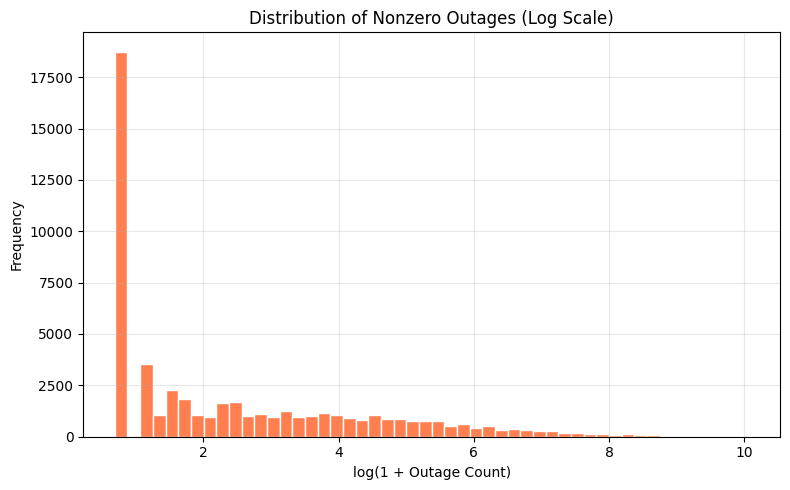

In [ ]:
out_all = ds_train.out.values.flatten()

print("=== Outage Distribution ===")
print(f"Total observations : {len(out_all):,}")
print(f"Zeros (no outage)  : {np.sum(out_all == 0):,}  ({100*np.mean(out_all == 0):.1f}%)")
print(f"out > 0            : {np.sum(out_all > 0):,}")
print(f"out > 100          : {np.sum(out_all > 100):,}")
print(f"out > 1000         : {np.sum(out_all > 1000):,}")
print(f"out > 5000         : {np.sum(out_all > 5000):,}")
print(f"Max outage         : {np.max(out_all):,.0f}")

# Histogram: nonzero outages, normal and log scale
nonzero = out_all[out_all > 0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(np.log1p(nonzero), bins=50, color='coral', edgecolor='white')
ax.set_xlabel("log(1 + Outage Count)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Nonzero Outages (Log Scale)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Spatial Distribution

#### 3.2.1 By Total Outage

Top 10 counties by total outage:
  County 26125: 1,723,876 outage-hours
  County 26163: 1,652,750 outage-hours
  County 26099: 920,650 outage-hours
  County 26161: 539,997 outage-hours
  County 26081: 233,530 outage-hours
  County 26103: 213,805 outage-hours
  County 26145: 200,134 outage-hours
  County 26093: 159,502 outage-hours
  County 26115: 149,918 outage-hours
  County 26049: 133,498 outage-hours


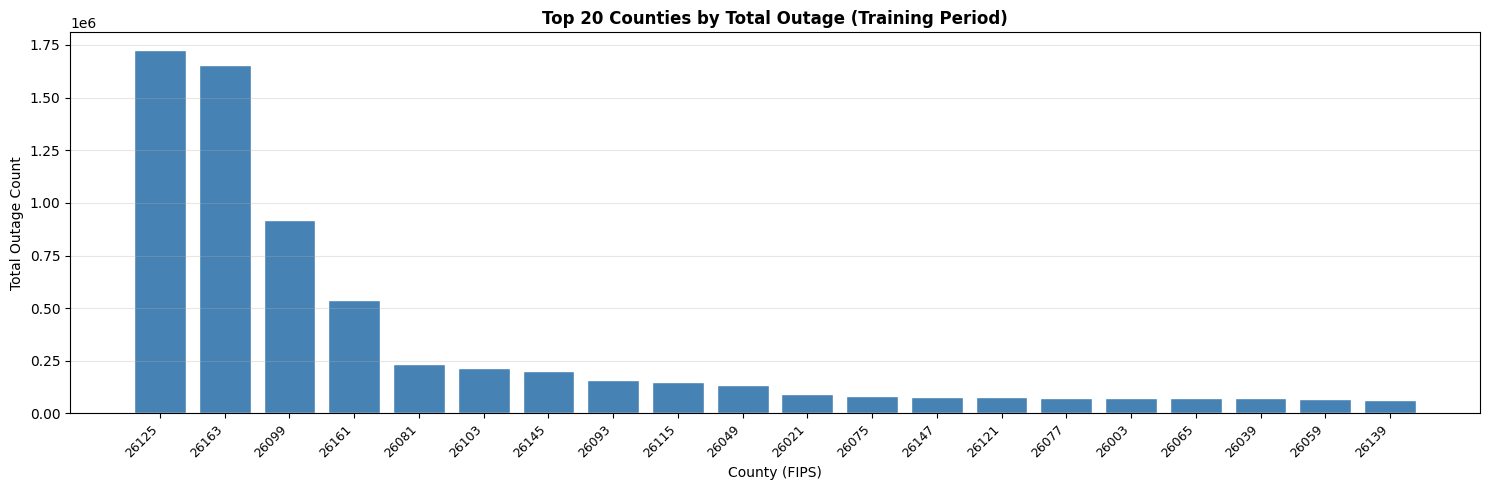

In [ ]:
total_outage_per_county = ds_train.out.sum(dim="timestamp").values
county_ids = list(ds_train.location.values)

sorted_idx = np.argsort(total_outage_per_county)[::-1]
sorted_counties = [county_ids[i] for i in sorted_idx]
sorted_outages = total_outage_per_county[sorted_idx]

print("Top 10 counties by total outage:")
for c, o in zip(sorted_counties[:10], sorted_outages[:10]):
    print(f"  County {c}: {o:,.0f} outage-hours")

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(20), sorted_outages[:20], color='steelblue', edgecolor='white')
ax.set_xticks(range(20))
ax.set_xticklabels(sorted_counties[:20], rotation=45, ha='right', fontsize=9)
ax.set_xlabel("County (FIPS)")
ax.set_ylabel("Total Outage Count")
ax.set_title("Top 20 Counties by Total Outage (Training Period)", fontweight="bold")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### 3.2.2 By Outage Rate

Top 10 counties by outage rate (outages per tracked household):
  County 26013: rate=0.0068
  County 26103: rate=0.0062
  County 26003: rate=0.0037
  County 26039: rate=0.0028
  County 26053: rate=0.0019
  County 26011: rate=0.0017
  County 26097: rate=0.0016
  County 26059: rate=0.0016
  County 26095: rate=0.0015
  County 26161: rate=0.0014


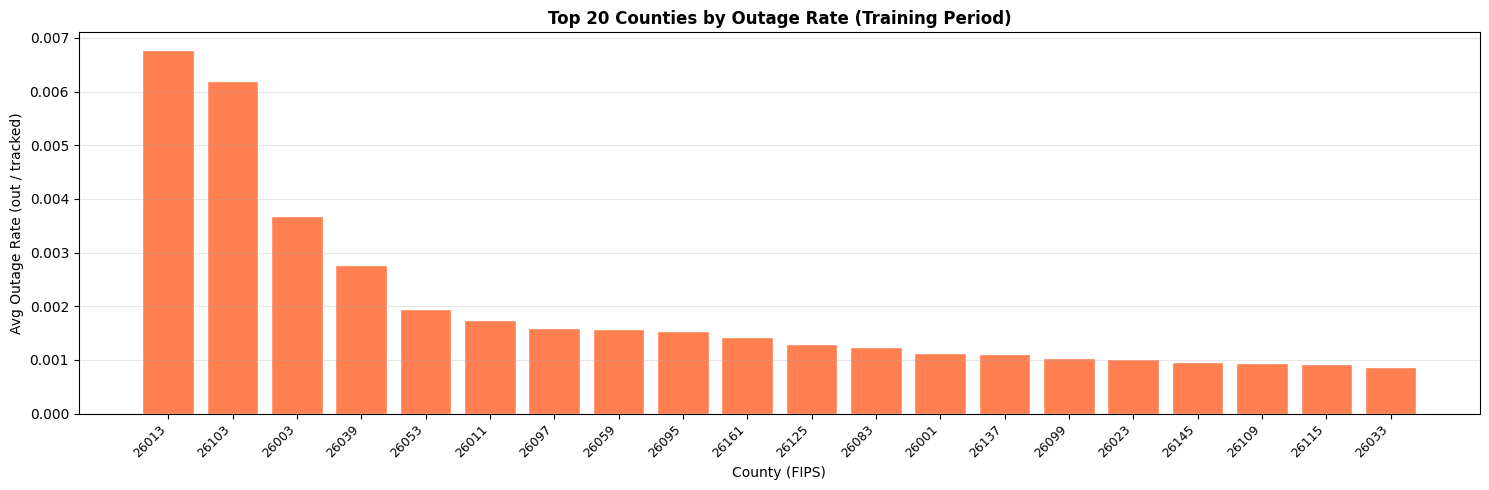

In [ ]:
tracked_mean_by_county = ds_train.tracked.mean(dim="timestamp").values
outage_mean_by_county  = ds_train.out.mean(dim="timestamp").values

outage_rate_by_county = np.where(
    tracked_mean_by_county > 0,
    outage_mean_by_county / tracked_mean_by_county,
    0.0
)

rate_sorted_idx      = np.argsort(outage_rate_by_county)[::-1]
rate_sorted_counties = [county_ids[i] for i in rate_sorted_idx]
rate_sorted_rates    = outage_rate_by_county[rate_sorted_idx]

print("Top 10 counties by outage rate (outages per tracked household):")
for c, r in zip(rate_sorted_counties[:10], rate_sorted_rates[:10]):
    print(f"  County {c}: rate={r:.4f}")

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(20), rate_sorted_rates[:20], color='coral', edgecolor='white')
ax.set_xticks(range(20))
ax.set_xticklabels(rate_sorted_counties[:20], rotation=45, ha='right', fontsize=9)
ax.set_xlabel("County (FIPS)")
ax.set_ylabel("Avg Outage Rate (out / tracked)")
ax.set_title("Top 20 Counties by Outage Rate (Training Period)", fontweight="bold")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 3.3 Major Extreme Events

Top 10 extreme outage events:
    County                  Timestamp      Outage     Tracked      Rate
----------------------------------------------------------------------
     26125        2023-06-26 07:00:00       23346      618124     0.038
     26125        2023-06-26 09:00:00       23277      618124     0.038
     26125        2023-06-26 08:00:00       23196      618124     0.038
     26125        2023-06-26 10:00:00       22979      618124     0.037
     26125        2023-06-26 06:00:00       22948      618124     0.037
     26125        2023-06-26 11:00:00       22605      618124     0.037
     26125        2023-06-26 12:00:00       22564      618124     0.037
     26125        2023-06-26 16:00:00       22471      618124     0.036
     26125        2023-06-26 05:00:00       22355      618124     0.036
     26125        2023-06-26 13:00:00       22190      618124     0.036


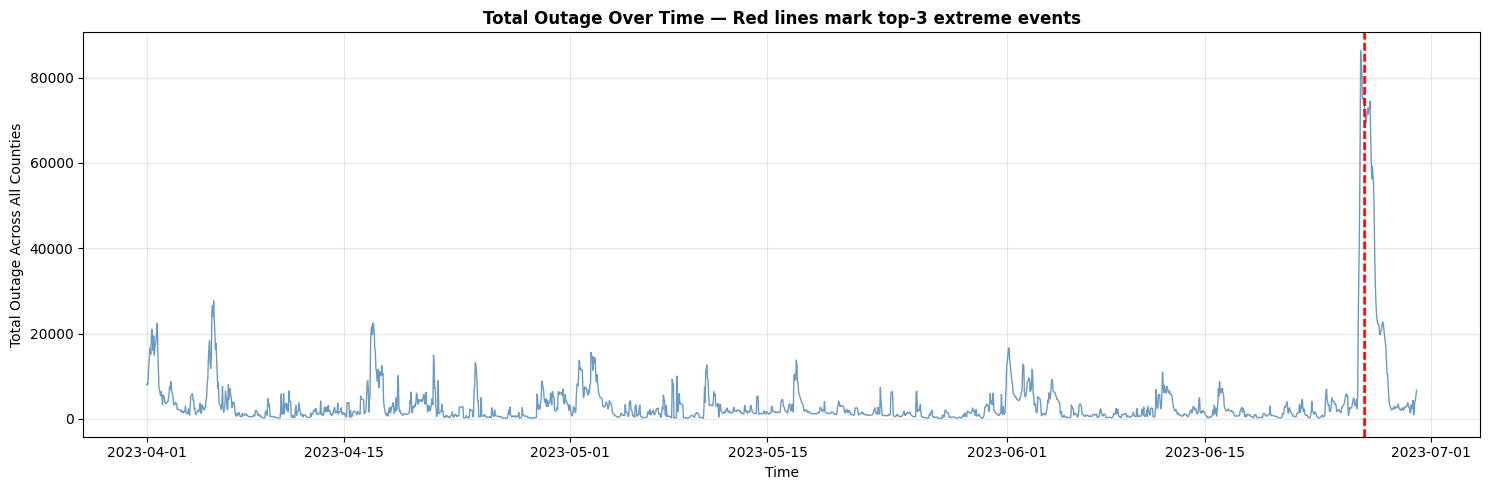

In [ ]:
total_outage_per_ts = ds_train.out.sum(dim="location").values  # (2161,)
out_arr = ds_train.out.values  # (83, 2161)
flat_idx = np.argsort(out_arr.flatten())[::-1][:10]
loc_idx_ext, ts_idx_ext = np.unravel_index(flat_idx, out_arr.shape)

print("Top 10 extreme outage events:")
print(f"{'County':>10}  {'Timestamp':>25}  {'Outage':>10}  {'Tracked':>10}  {'Rate':>8}")
print("-" * 70)
for li, ti in zip(loc_idx_ext, ts_idx_ext):
    county   = county_ids[li]
    ts_val   = train_timestamps[ti]
    out_val  = out_arr[li, ti]
    trk_val  = ds_train.tracked.values[li, ti]
    rate     = out_val / trk_val if trk_val > 0 else 0
    print(f"{county:>10}  {str(ts_val):>25}  {out_val:>10.0f}  {trk_val:>10.0f}  {rate:>8.3f}")

# Total outage over time with extreme event markers
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_timestamps, total_outage_per_ts, color='steelblue', linewidth=1, alpha=0.8)
for li, ti in zip(loc_idx_ext[:3], ts_idx_ext[:3]):
    ax.axvline(x=train_timestamps[ti], color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.set_xlabel("Time")
ax.set_ylabel("Total Outage Across All Counties")
ax.set_title("Total Outage Over Time — Red lines mark top-3 extreme events", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Temporal Trends in Large Counties — Outage History in Top 5 Population Counties

Top 5 locations by population: ['26163', '26125', '26099', '26081', '26049']


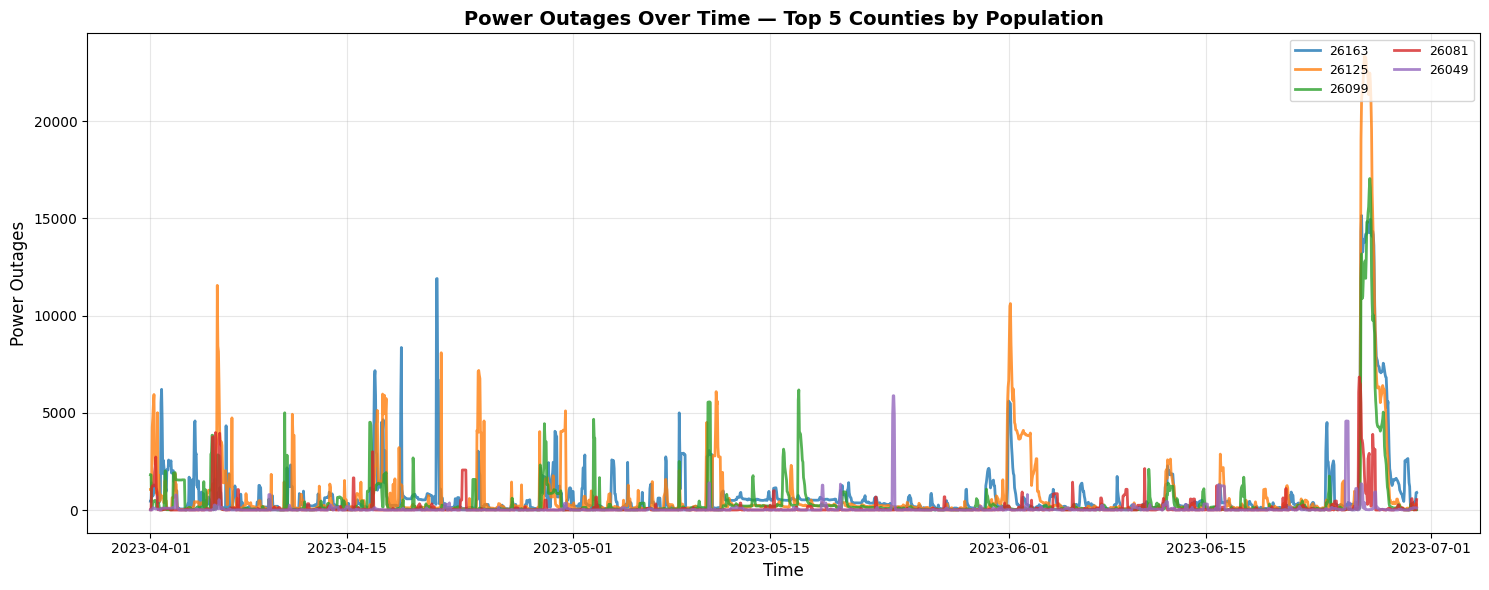

In [ ]:
# 1) Compute population per county
pop_by_loc = ds_train.tracked.mean(dim="timestamp")

# 2) Get top 5 locations by population
top5_locs = (
    pop_by_loc
    .sortby(pop_by_loc, ascending=False)
    .isel(location=slice(0, 5))
    .location
    .values
)

print("Top 5 locations by population:", [str(x) for x in top5_locs])

# 3) Plot their outages over time
fig, ax = plt.subplots(figsize=(15, 6))

for loc in top5_locs:
    outages = ds_train.out.sel(location=loc).values
    ax.plot(train_timestamps, outages, label=str(loc), alpha=0.8, linewidth=2)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Power Outages", fontsize=12)
ax.set_title("Power Outages Over Time — Top 5 Counties by Population",
             fontsize=14, fontweight="bold")
ax.legend(ncol=2, fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Periodic Cycles — Average Outages by Hour and Day

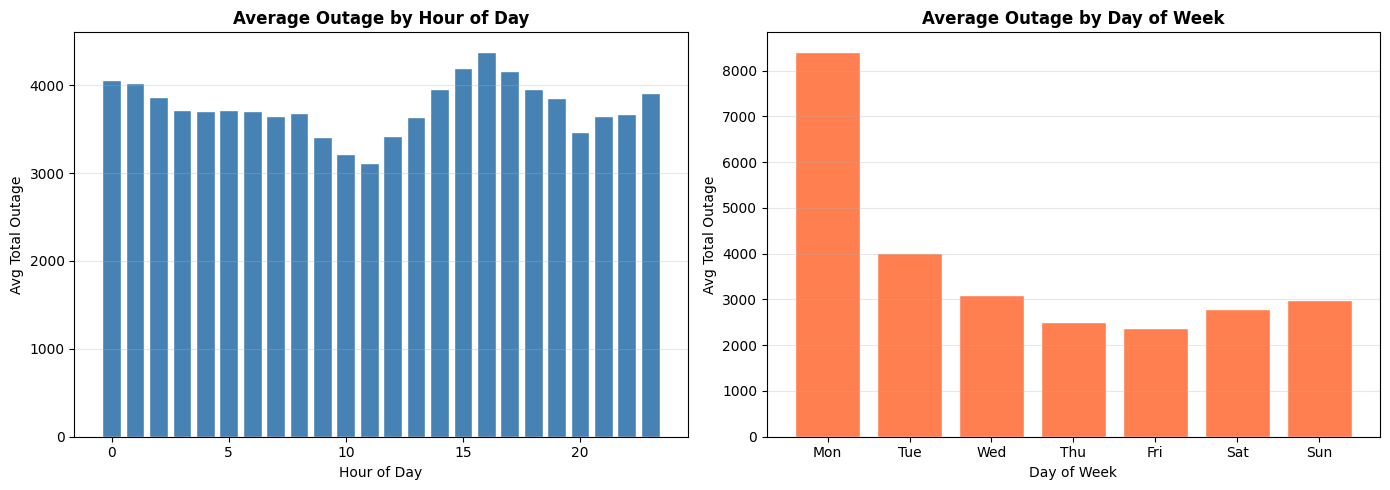

In [ ]:
ts_series = pd.Series(total_outage_per_ts, index=train_timestamps)

hourly_avg = ts_series.groupby(ts_series.index.hour).mean()
daily_avg  = ts_series.groupby(ts_series.index.dayofweek).mean()
day_names  = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Avg Total Outage")
axes[0].set_title("Average Outage by Hour of Day", fontweight="bold")
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(7), daily_avg.values, color='coral', edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Avg Total Outage")
axes[1].set_title("Average Outage by Day of Week", fontweight="bold")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.6 Feature Correlation with Outages — Top 15 Correlated Weather Features

This analysis directly informs feature selection for the Minimal Effort baseline.

Top 15 features most correlated with outage:
cape         0.119191
pwat         0.089700
sh2          0.083554
gh_4         0.081504
cape_1       0.073289
sdlwrf       0.068874
unknown_3    0.061608
refc         0.059532
lcc          0.055376
hail         0.054625
cnwat        0.054364
tcc          0.053949
pcdb         0.053770
gh          -0.052808
lftx        -0.052581


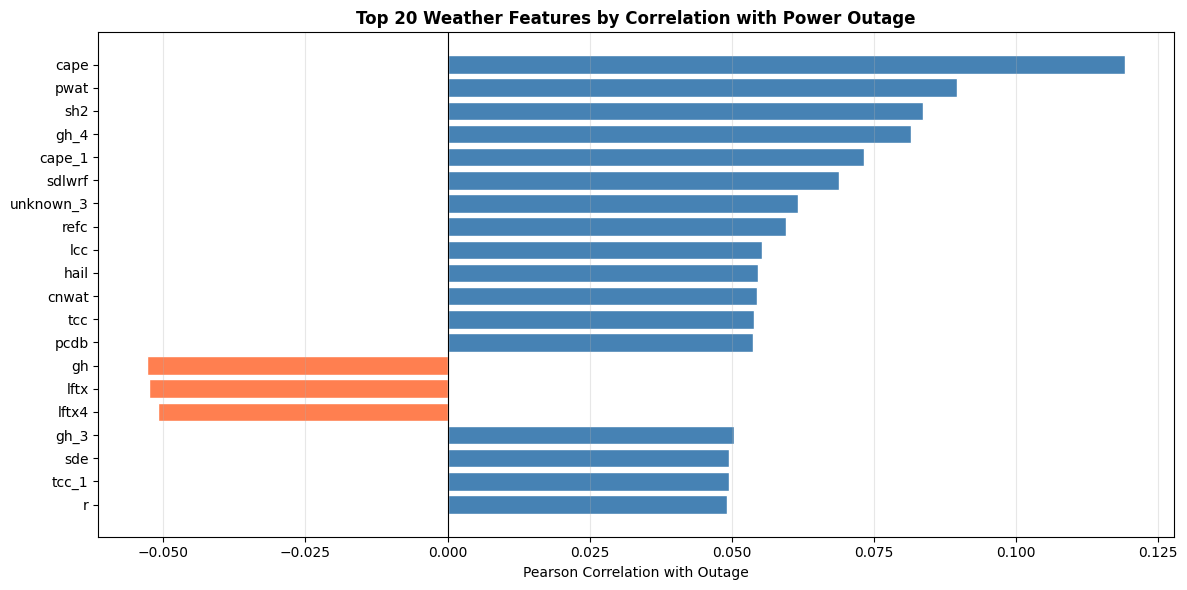

In [ ]:
w_full = ds_train.weather.values   # (83, 2161, 109)
o_full = ds_train.out.values       # (83, 2161)

w_flat = w_full.reshape(-1, len(weather_features))
o_flat = o_full.reshape(-1)

feature_stds = np.std(w_flat, axis=0)
valid_feature_mask = feature_stds > 1e-6

corr_vals = []
for fi in range(len(weather_features)):
    if not valid_feature_mask[fi]:
        corr_vals.append(0.0)
    else:
        c = np.corrcoef(w_flat[:, fi], o_flat)[0, 1]
        corr_vals.append(0.0 if np.isnan(c) else c)

corr_series = pd.Series(corr_vals, index=weather_features).sort_values(key=abs, ascending=False)

print("Top 15 features most correlated with outage:")
print(corr_series.head(15).to_string())

top20 = corr_series.head(20)
colors = ['steelblue' if v >= 0 else 'coral' for v in top20.values]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Outage")
ax.set_title("Top 20 Weather Features by Correlation with Power Outage", fontweight="bold")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 3.7 CAPE (Convective Available Potential Energy) and Outage Correlation

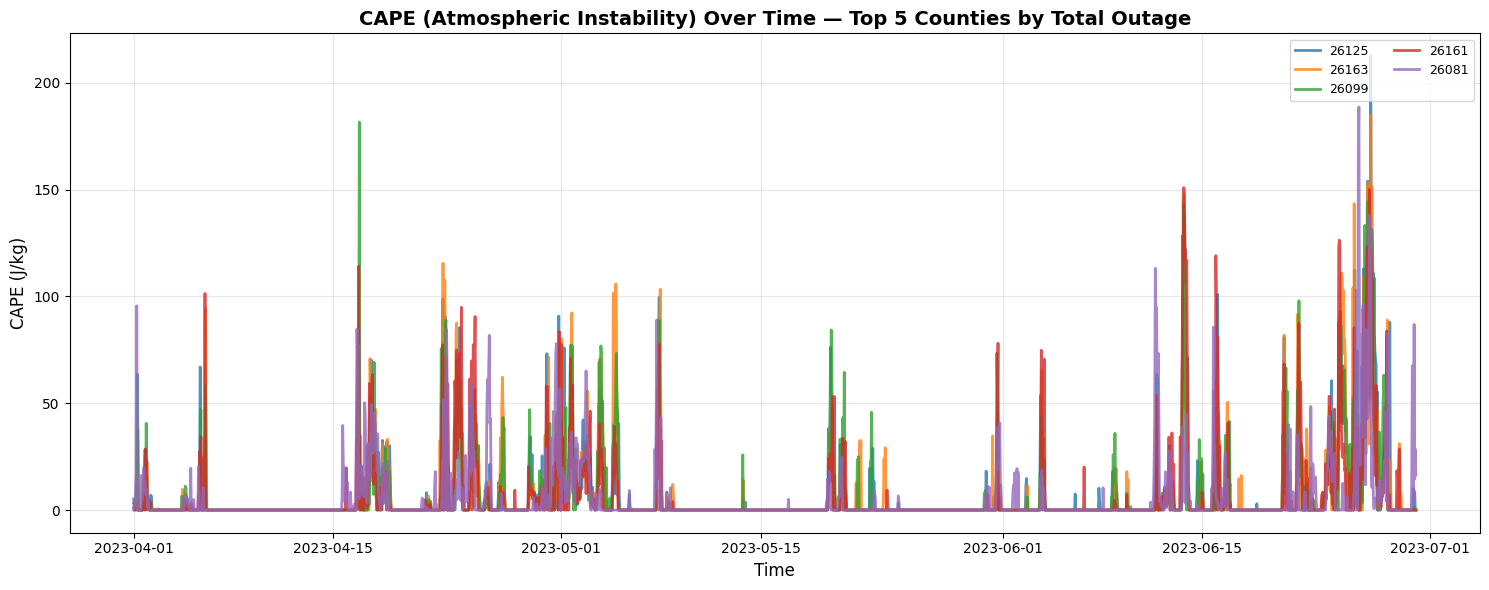


CAPE Statistics for Top 5 Counties by Total Outage:
  26125: Mean=6.69 J/kg, Max=212.60 J/kg
  26163: Mean=6.68 J/kg, Max=184.90 J/kg
  26099: Mean=6.27 J/kg, Max=181.70 J/kg
  26161: Mean=6.13 J/kg, Max=151.00 J/kg
  26081: Mean=4.91 J/kg, Max=188.70 J/kg


In [ ]:
# CAPE time series for top 5 counties
top5_outage_locs = sorted_counties[:5]

cape_idx = weather_features.index('cape')
fig, ax = plt.subplots(figsize=(15, 6))
for loc in top5_outage_locs:
    cape_data = ds_train.weather.sel(location=loc, feature='cape').values
    ax.plot(train_timestamps, cape_data, label=str(loc), alpha=0.8, linewidth=2)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("CAPE (J/kg)", fontsize=12)
ax.set_title("CAPE (Atmospheric Instability) Over Time — Top 5 Counties by Total Outage",
             fontsize=14, fontweight="bold")
ax.legend(ncol=2, fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCAPE Statistics for Top 5 Counties by Total Outage:")
for loc in top5_outage_locs:
    cape_data = ds_train.weather.sel(location=loc, feature='cape').values
    print(f"  {loc}: Mean={np.nanmean(cape_data):.2f} J/kg, "
          f"Max={np.nanmax(cape_data):.2f} J/kg")


==================== Correlation: CAPE vs. Power Outages ====================

County 26125: +0.4099
County 26163: +0.3078
County 26099: +0.3755
County 26161: +0.3677
County 26081: +0.2860


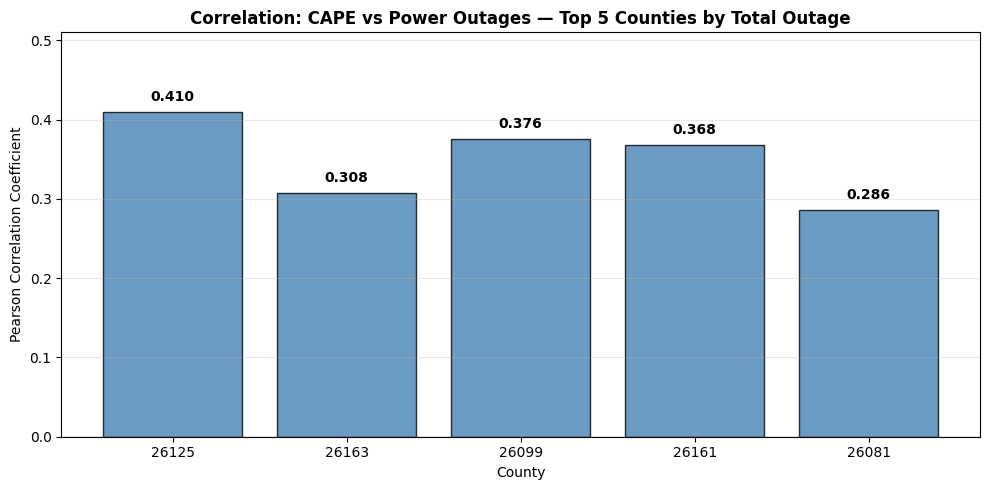

In [ ]:
# Correlation between CAPE and outage per county
print(f"\n{'='*20} Correlation: CAPE vs. Power Outages {'='*20}\n")
correlations = {}
for loc in top5_outage_locs:
    cape_data = ds_train.weather.sel(location=loc, feature='cape').values
    outage_data_loc = ds_train.out.sel(location=loc).values

    valid_mask = ~(np.isnan(cape_data) | np.isnan(outage_data_loc))
    cape_clean = cape_data[valid_mask]
    outage_clean = outage_data_loc[valid_mask]

    if len(cape_clean) > 1:
        correlation = np.corrcoef(cape_clean, outage_clean)[0, 1]
        correlations[str(loc)] = correlation
        print(f"County {loc}: {correlation:+.4f}")
    else:
        correlations[str(loc)] = np.nan

fig, ax = plt.subplots(figsize=(10, 5))
counties_list = list(correlations.keys())
corr_values   = list(correlations.values())
colors = ['steelblue' if c > 0 else 'coral' for c in corr_values]

bars = ax.bar(counties_list, corr_values, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('County')
ax.set_ylabel('Pearson Correlation Coefficient')
ax.set_title('Correlation: CAPE vs Power Outages — Top 5 Counties by Total Outage',
             fontweight='bold')
ax.set_ylim(0, max(corr_values) + 0.1)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, corr_values):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preparation & Helper Functions

### 4.1 Train / Validation Split

In [ ]:
# Create validation split (temporal split)
n_timestamps = len(train_timestamps)
split_idx = int(n_timestamps * (1 - VALIDATION_SPLIT))

ds_train_sub = ds_train.isel(timestamp=slice(0, split_idx))
ds_val       = ds_train.isel(timestamp=slice(split_idx, None))

train_sub_timestamps = pd.to_datetime(ds_train_sub.timestamp.values)
val_timestamps       = pd.to_datetime(ds_val.timestamp.values)

print(f"Training Subset: {len(train_sub_timestamps)} timestamps")
print(f"  Period: {train_sub_timestamps.min()} to {train_sub_timestamps.max()}")
print(f"\nValidation Set: {len(val_timestamps)} timestamps")
print(f"  Period: {val_timestamps.min()} to {val_timestamps.max()}")

# Store validation ground truth for later evaluation
val_truth = ds_val.out.transpose("timestamp", "location").values.astype(float)

Training Subset: 1728 timestamps
  Period: 2023-04-01 00:00:00 to 2023-06-11 23:00:00

Validation Set: 433 timestamps
  Period: 2023-06-12 00:00:00 to 2023-06-30 00:00:00


In [ ]:
# Ground truth last 24 and 48 hours to align with test set
val_truth_24h = ds_val.out.transpose("timestamp","location").isel(timestamp=slice(0,24)).values.astype(float)
val_truth_48h = ds_val.out.transpose("timestamp","location").isel(timestamp=slice(0,48)).values.astype(float)

print(f"\nValidation set shapes:")
print(f"  24h: {val_truth_24h.shape}")
print(f"  48h: {val_truth_48h.shape}")


Validation set shapes:
  24h: (24, 83)
  48h: (48, 83)


In [ ]:
test_24h_truth = ds_test_24h.out.transpose("timestamp", "location").values.astype(float)
test_48h_truth = ds_test_48h.out.transpose("timestamp", "location").values.astype(float)

print(f"\nTest shapes:")
print(f"  24h: {test_24h_truth.shape}")
print(f"  48h: {test_48h_truth.shape}")


Test shapes:
  24h: (24, 83)
  48h: (48, 83)


### 4.2 Remove Zero-Variance Features

In [ ]:
# Identify and remove zero-variance features
w_flat_full = ds_train.weather.values.reshape(-1, len(weather_features))
feature_stds = np.std(w_flat_full, axis=0)

valid_feature_mask = feature_stds > 1e-6
valid_features   = [f for f, keep in zip(weather_features, valid_feature_mask) if keep]
removed_features = [f for f, keep in zip(weather_features, valid_feature_mask) if not keep]

print(f"Original features : {len(weather_features)}")
print(f"Removed (zero var): {len(removed_features)}")
print(f"  {removed_features}")
print(f"Remaining features: {len(valid_features)}")

# Filter datasets
ds_train_filtered     = ds_train.sel(feature=valid_features)
ds_train_sub_filtered = ds_train_sub.sel(feature=valid_features)
ds_val_filtered       = ds_val.sel(feature=valid_features)

N_FEATURES = len(valid_features)
print(f"\nFiltered weather shape (train): {ds_train_filtered.weather.shape}")

Original features : 109
Removed (zero var): 18
  ['aod', 'bgrun', 'cfrzr', 'cicep', 'crain', 'csnow', 'hail_2', 'ltng', 'mdens', 'prate', 'sdwe_1', 'siconc', 'ssrun', 'tcoli', 'tcolw', 'tp', 'unknown_7', 'unknown_9']
Remaining features: 91

Filtered weather shape (train): (83, 2161, 91)


### 4.3 Feature Matrix for Baseline Models

In [ ]:
from sklearn.preprocessing import StandardScaler

# Shape: (T, 83, F) → flatten to (T*83, F)
w_train = ds_train_sub_filtered.weather.transpose("timestamp","location","feature").values.astype(float)
o_train = ds_train_sub_filtered.out.transpose("timestamp","location").values.astype(float)

w_val = ds_val_filtered.weather.transpose("timestamp","location","feature").values.astype(float)
o_val = ds_val_filtered.out.transpose("timestamp","location").values.astype(float)

T_train, L, F = w_train.shape
T_val = w_val.shape[0]

X_train_flat = w_train.reshape(-1, F)
y_train_flat = o_train.reshape(-1)

X_val_flat = w_val.reshape(-1, F)
y_val_flat = o_val.reshape(-1)

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled   = scaler.transform(X_val_flat)

print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_val_scaled   : {X_val_scaled.shape}")

X_train_scaled : (143424, 91)
X_val_scaled   : (35939, 91)


### 4.4 Evaluation Metric Functions

In [ ]:
def rmse(y_true, y_pred):
    """Calculate Root Mean Squared Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def evaluate_per_county(truth, pred_df, locations):
    """Evaluate RMSE per county and return list of RMSEs."""
    rmses = []
    for i, loc in enumerate(locations):
        loc_str = str(loc)
        loc_pred = pred_df[pred_df['location'].astype(str) == loc_str]['pred'].values
        if len(loc_pred) == truth.shape[0]:
            rmses.append(rmse(truth[:, i], loc_pred))
        else:
            rmses.append(np.nan)
    return rmses

# def mae(y_true, y_pred):
#     """Calculate Mean Absolute Error."""
#     y_true = np.asarray(y_true, dtype=float)
#     y_pred = np.asarray(y_pred, dtype=float)
#     return float(np.mean(np.abs(y_true - y_pred)))

## 5. Baseline Models

Simple baselines to benchmark against SARIMAX and Seq2Seq.

### 5.1 Baseline 1 — Zero Prediction
Since 70.5% of observations are zero, predicting outage = 0 for all counties and hours should be a meaningful lower bound.

In [ ]:
val_timestamps_24h = val_timestamps[:24]
val_timestamps_48h = val_timestamps[:48]

def make_zero_pred_df(timestamps, locations):
    """Build a zero-prediction DataFrame in submission format."""
    rows = []
    for ts in timestamps:
        for loc in locations:
            rows.append({"timestamp": ts, "location": str(loc), "pred": 0.0})
    return pd.DataFrame(rows)

zero_val_24h_df = make_zero_pred_df(val_timestamps_24h, locations)
zero_val_48h_df = make_zero_pred_df(val_timestamps_48h, locations)

zero_24h_rmses = evaluate_per_county(val_truth_24h, zero_val_24h_df, locations)
zero_48h_rmses = evaluate_per_county(val_truth_48h, zero_val_48h_df, locations)

print(f"Zero Prediction — Val RMSE (24h): {np.nanmean(zero_24h_rmses):.4f}")
print(f"Zero Prediction — Val RMSE (48h): {np.nanmean(zero_48h_rmses):.4f}")

Zero Prediction — Val RMSE (24h): 100.3053
Zero Prediction — Val RMSE (48h): 75.3561


### 5.2 Baseline 2 — Minimal Effort (EDA-guided Feature Selection)
Based on the correlation analysis in Section 3.6, we select the top 10 correlated features and train a simple linear regression — no tuning, no cross-validation.

Top 10 features selected (from EDA): `cape`, `pwat`, `sh2`, `gh_4`, `cape_1`, `sdlwrf`, `unknown_3`, `refc`, `lcc`, `hail`

This reflects the "minimal effort" of translating EDA insight directly into a model.

In [ ]:
# First analyze correlation between cape and cape_1
idx_cape = valid_features.index('cape')
idx_cape1 = valid_features.index('cape_1')
cape_corr = np.corrcoef(X_train_scaled[:, idx_cape], X_train_scaled[:, idx_cape1])[0, 1]

print(f"Correlation between cape and cape_1: {cape_corr:.4f}")

MINIMAL_FEATURES = corr_series.head(10).index.tolist()
if abs(cape_corr) > 0.9 and 'cape_1' in MINIMAL_FEATURES:
    MINIMAL_FEATURES.remove('cape_1')
    print(f"Insight: High correlation detected. Removed 'cape_1' from Top 10.")
else:
    print(f"Insight: Correlation is within acceptable limits.")

Correlation between cape and cape_1: 0.3601
Insight: Correlation is within acceptable limits.


In [ ]:
from sklearn.linear_model import LinearRegression

MINIMAL_FEATURES = [f for f in MINIMAL_FEATURES if f in valid_features]
feat_idx = [valid_features.index(f) for f in MINIMAL_FEATURES]

X_train_min = X_train_scaled[:, feat_idx]
y_train_log = np.log1p(y_train_flat)

lr_minimal = LinearRegression()
lr_minimal.fit(X_train_min, y_train_log)

def minimal_pred_df(model, feat_idx, X_val_scaled_full, timestamps, locations, n_hours):
    """Generate minimal-effort predictions using log-inverse transformation."""
    L = len(locations)
    X_all = X_val_scaled_full.reshape(T_val, L, -1)
    X = X_all[:n_hours].reshape(n_hours * L, -1)[:, feat_idx]

    pred_log = model.predict(X)
    pred = np.expm1(pred_log).clip(0).reshape(n_hours, L)

    rows = []
    for ti, ts in enumerate(timestamps):
        for li, loc in enumerate(locations):
            rows.append({"timestamp": ts, "location": str(loc), "pred": pred[ti, li]})
    return pd.DataFrame(rows)

minimal_val_24h_df = minimal_pred_df(lr_minimal, feat_idx, X_val_scaled,
                                      val_timestamps_24h, locations, 24)
minimal_val_48h_df = minimal_pred_df(lr_minimal, feat_idx, X_val_scaled,
                                      val_timestamps_48h, locations, 48)

minimal_24h_rmses = evaluate_per_county(val_truth_24h, minimal_val_24h_df, locations)
minimal_48h_rmses = evaluate_per_county(val_truth_48h, minimal_val_48h_df, locations)

print(f"Minimal Effort (Top {len(MINIMAL_FEATURES)}) — Val RMSE (24h): {np.nanmean(minimal_24h_rmses):.4f}")
print(f"Minimal Effort (Top {len(MINIMAL_FEATURES)}) — Val RMSE (48h): {np.nanmean(minimal_48h_rmses):.4f}")

Minimal Effort (Top 10) — Val RMSE (24h): 100.3562
Minimal Effort (Top 10) — Val RMSE (48h): 75.4972


### 5.3 Baseline Summary

In [ ]:
baseline_summary = pd.DataFrame({
    "Model": ["Zero Prediction", "Minimal Effort"],
    "Val RMSE (24h)": [round(np.nanmean(zero_24h_rmses), 4),
                       round(np.nanmean(minimal_24h_rmses), 4)],
    "Val RMSE (48h)": [round(np.nanmean(zero_48h_rmses), 4),
                       round(np.nanmean(minimal_48h_rmses), 4)],
})
print("\nBASELINE COMPARISON — VALIDATION SET")
print(baseline_summary.to_string(index=False))


BASELINE COMPARISON — VALIDATION SET
          Model  Val RMSE (24h)  Val RMSE (48h)
Zero Prediction        100.3053         75.3561
 Minimal Effort        100.3562         75.4972


## 6. Model Structure and Functions

We'll define two types of models:
1. **SARIMAX** - Statistical time series model (per-county)
2. **Seq2Seq LSTM** - Deep learning model (shared across counties but different for two horizons)

### 6.1 SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def safe_fit_sarimax(y, order=(1, 0, 1)):
    """Safely fit SARIMAX model with error handling."""
    y = np.asarray(y, dtype=float).flatten()
    if len(y) < 8 or np.allclose(y, y[0]):
        return None
    try:
        model = SARIMAX(y, order=order, enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        return res
    except Exception as e:
        print(f"  Warning: SARIMAX fit failed - {str(e)[:50]}")
        return None


### 6.2 Seq2Seq

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import time

# Set random seed for PyTorch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Define Seq2Seq Model
class SimpleSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_dim, horizon)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h, _) = self.lstm(x)
        h_last = h[-1]  # (batch, hidden_dim)
        return self.head(h_last)  # (batch, horizon)

print(f"Device: {DEVICE}")

In [ ]:
# Utility functions for Seq2Seq
def z_normalize_fit(arr):
    """Compute mean and std for normalization."""
    mu = np.nanmean(arr, axis=0)
    sd = np.nanstd(arr, axis=0)
    sd = np.where(sd == 0, 1.0, sd)
    return mu, sd

def z_normalize_apply(arr, mu, sd):
    """Apply normalization with precomputed mean and std."""
    return (arr - mu) / sd

def build_sliding_windows(X_loc, y_loc, seq_len, horizon):
    """
    Build sliding windows for one location.
    X_loc: (T, D) features
    y_loc: (T,) targets
    Returns: X_windows (N, seq_len, D), Y_windows (N, horizon)
    """
    N = len(y_loc) - seq_len - horizon + 1
    if N <= 0:
        return np.empty((0, seq_len, X_loc.shape[1]), dtype=float), np.empty((0, horizon), dtype=float)

    X_windows, Y_windows = [], []
    for i in range(N):
        X_windows.append(X_loc[i:i+seq_len])
        Y_windows.append(y_loc[i+seq_len:i+seq_len+horizon])

    return np.array(X_windows, dtype=float), np.array(Y_windows, dtype=float)

print("Helper functions defined.")

In [ ]:
# Prepare training data for Seq2Seq (using training subset)
def prepare_seq2seq_data(ds, seq_len, horizon):
    """
    Prepare data for Seq2Seq training.
    Features: [outage_scaled, weather_features_scaled]
    """
    y = ds.out.transpose("timestamp", "location").values.astype(float)  # (T, L)
    w = ds.weather.transpose("timestamp", "location", "feature").values.astype(float)  # (T, L, F)
    T, L, F = w.shape

    # Compute global scalers
    y_mu, y_sd = z_normalize_fit(y.reshape(-1, 1))
    w_mu, w_sd = z_normalize_fit(w.reshape(-1, F))

    # Apply scaling
    y_scaled = z_normalize_apply(y.reshape(-1, 1), y_mu, y_sd).reshape(T, L)
    w_scaled = z_normalize_apply(w.reshape(-1, F), w_mu, w_sd).reshape(T, L, F)

    # Build windows for all locations
    input_dim = 1 + F  # outage + weather features
    X_list, Y_list = [], []

    for li in range(L):
        y_loc = y_scaled[:, li]  # (T,)
        w_loc = w_scaled[:, li, :]  # (T, F)
        X_loc = np.concatenate([y_loc.reshape(-1, 1), w_loc], axis=1)  # (T, 1+F)

        X_win, Y_win = build_sliding_windows(X_loc, y_loc, seq_len, horizon)
        if len(X_win) > 0:
            X_list.append(X_win)
            Y_list.append(Y_win)

    X = np.concatenate(X_list, axis=0) if X_list else np.empty((0, seq_len, input_dim))
    Y = np.concatenate(Y_list, axis=0) if Y_list else np.empty((0, horizon))

    scalers = {"y_mu": y_mu, "y_sd": y_sd, "w_mu": w_mu, "w_sd": w_sd}
    return X, Y, input_dim, scalers

# Use validation set length as horizon for training
val_horizon = len(val_timestamps)
print(f"Preparing Seq2Seq training data with horizon={val_horizon}...")

X_train, Y_train, input_dim, seq2seq_scalers = prepare_seq2seq_data(ds_train_sub, SEQ_LEN, val_horizon)

print(f"Training windows created: {X_train.shape[0]} samples")
print(f"Input shape: {X_train.shape} (samples, seq_len, features)")
print(f"Output shape: {Y_train.shape} (samples, horizon)")
print(f"Input dimension: {input_dim}")

In [ ]:
# Train Seq2Seq model
def train_seq2seq(X, Y, input_dim, horizon, epochs=5, batch_size=64, lr=1e-3):
    """Train Seq2Seq model."""
    if len(X) == 0:
        print("No training data available!")
        return None

    # Create dataset and dataloader
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(Y, dtype=torch.float32)
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    model = SimpleSeq2Seq(
        input_dim=input_dim,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        horizon=horizon
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    print(f"\nTraining Seq2Seq model for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        for xb, yb in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(dataset)
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f} - Time: {elapsed:.2f}s")

    return model


### 6.3 Prediction Functions

Define reusable prediction functions that will be used for both validation and test sets.

In [ ]:
# Consolidated prediction functions for reuse

def generate_sarimax_predictions(models_dict, locations, timestamps):
    """
    Generate SARIMAX predictions for given timestamps.
    Returns: DataFrame in long format (timestamp, location, pred)
    """
    rows = []
    n_steps = len(timestamps)

    for loc in locations:
        loc_str = str(loc)
        if loc_str in models_dict and models_dict[loc_str] is not None:
            try:
                pred = np.asarray(models_dict[loc_str].forecast(steps=n_steps), dtype=float)
                pred = np.clip(pred, 0, None)  # Non-negative constraint
            except:
                pred = np.zeros(n_steps)
        else:
            pred = np.zeros(n_steps)

        rows.append(pd.DataFrame({
            "timestamp": timestamps,
            "location": loc_str,
            "pred": pred
        }))

    return pd.concat(rows, ignore_index=True)

@torch.no_grad()
def generate_seq2seq_predictions(model, ds_train_data, scalers, horizon, timestamps, locations):
    """
    Generate Seq2Seq predictions for given horizon.
    Returns: DataFrame in long format (timestamp, location, pred)
    """
    if model is None:
        # Return zeros if model not available
        locs_repeated = np.repeat([str(loc) for loc in locations], horizon)
        ts_repeated = np.tile(timestamps, len(locations))
        return pd.DataFrame({
            "timestamp": ts_repeated,
            "location": locs_repeated,
            "pred": 0.0
        })

    model.eval()

    y = ds_train_data.out.transpose("timestamp", "location").values.astype(float)
    w = ds_train_data.weather.transpose("timestamp", "location", "feature").values.astype(float)
    T, L, F = w.shape

    # Apply scaling
    y_scaled = z_normalize_apply(y.reshape(-1, 1), scalers["y_mu"], scalers["y_sd"]).reshape(T, L)
    w_scaled = z_normalize_apply(w.reshape(-1, F), scalers["w_mu"], scalers["w_sd"]).reshape(T, L, F)

    predictions = []

    for li in range(L):
        if T < SEQ_LEN:
            pred_scaled = np.zeros(horizon)
        else:
            # Get last SEQ_LEN timesteps
            y_loc = y_scaled[:, li]
            w_loc = w_scaled[:, li, :]
            X_loc = np.concatenate([y_loc.reshape(-1, 1), w_loc], axis=1)
            X_in = X_loc[-SEQ_LEN:].reshape(1, SEQ_LEN, -1)

            # Predict
            X_tensor = torch.tensor(X_in, dtype=torch.float32).to(DEVICE)
            pred_scaled = model(X_tensor).cpu().numpy()[0]

        # Inverse scaling
        pred = (pred_scaled * scalers["y_sd"].flatten()[0]) + scalers["y_mu"].flatten()[0]
        pred = np.clip(pred, 0, None)  # Non-negative constraint
        predictions.append(pred)

    # Convert to DataFrame in long format
    preds_array = np.array(predictions).T  # (horizon, L)
    rows = []
    for i, loc in enumerate(locations):
        rows.append(pd.DataFrame({
            "timestamp": timestamps,
            "location": str(loc),
            "pred": preds_array[:, i]
        }))

    return pd.concat(rows, ignore_index=True)

## 7. Validation Set (24h and 48h)

Evaluate models on 24h and 48h prediction horizons separately, matching the test set structure.

In [ ]:
# Define horizons
horizon_24h_val = 24
horizon_48h_val = 48

# Extract validation timestamps for each horizon
val_timestamps_24h = val_timestamps[:24]
val_timestamps_48h = val_timestamps[:48]

### 7.1 Train Models

In [ ]:
# Train SARIMAX models per county on training subset
print("Training SARIMAX models (one per county)...\n")
sarimax_models = {}

# Notice we fixed SARIMAX_ORDER for all counties, however, one can easily tune it over validation set for each county.
for loc in locations:
    print(f"Fitting SARIMAX for {loc}...", end=" ")
    y_train = ds_train_sub.out.sel(location=loc).values.astype(float).flatten()
    model = safe_fit_sarimax(y_train, order=SARIMAX_ORDER)
    sarimax_models[loc] = model
    if model is not None:
        print(f"✓ Success (AIC: {model.aic:.2f})")
    else:
        print("✗ Failed (will use zero baseline)")

print(f"\nSARIMAX training complete!")

In [ ]:
# Train SASeq2Seq models per county on training subset
print("Training Seq2Seq models (one per time horizon for all counties)...\n")
print(f"\nValidation horizons:")
print(f"  24h: {len(val_timestamps_24h)} timestamps")
print(f"  48h: {len(val_timestamps_48h)} timestamps")

# Train for 24h horizon
print(f"\n{'='*70}")
print("Training Seq2Seq for 24h horizon...")
print(f"{'='*70}")
X_train_24h, Y_train_24h, input_dim, seq2seq_scalers_24h = prepare_seq2seq_data(ds_train_sub, SEQ_LEN, horizon_24h_val)
print(f"Training samples: {X_train_24h.shape[0]}")

seq2seq_model_24h_val = train_seq2seq(
    X_train_24h, Y_train_24h, input_dim, horizon_24h_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

# Train for 48h horizon
print(f"\n{'='*70}")
print("Training Seq2Seq for 48h horizon...")
print(f"{'='*70}")
X_train_48h, Y_train_48h, _, seq2seq_scalers_48h = prepare_seq2seq_data(ds_train_sub, SEQ_LEN, horizon_48h_val)
print(f"Training samples: {X_train_48h.shape[0]}")

seq2seq_model_48h_val = train_seq2seq(
    X_train_48h, Y_train_48h, input_dim, horizon_48h_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

print("\n✓ Seq2Seq models trained for both horizons!")

### 7.2 Generate Predictions

In [ ]:
# Generate predictions using consolidated functions
print("Generating predictions for validation set...\n")

# SARIMAX predictions (same models for both horizons, just different forecast lengths)
print("1) SARIMAX predictions...")
sarimax_val_pred_24h_df = generate_sarimax_predictions(sarimax_models, locations, val_timestamps_24h)
sarimax_val_pred_48h_df = generate_sarimax_predictions(sarimax_models, locations, val_timestamps_48h)
print(f"   24h: {len(sarimax_val_pred_24h_df)} predictions")
print(f"   48h: {len(sarimax_val_pred_48h_df)} predictions")

# Seq2Seq predictions
print("\n2) Seq2Seq predictions...")
seq2seq_val_pred_24h_df = generate_seq2seq_predictions(
    seq2seq_model_24h_val, ds_train_sub, seq2seq_scalers_24h,
    horizon_24h_val, val_timestamps_24h, locations
)
seq2seq_val_pred_48h_df = generate_seq2seq_predictions(
    seq2seq_model_48h_val, ds_train_sub, seq2seq_scalers_48h,
    horizon_48h_val, val_timestamps_48h, locations
)
print(f"   24h: {len(seq2seq_val_pred_24h_df)} predictions")
print(f"   48h: {len(seq2seq_val_pred_48h_df)} predictions")

print("\n✓ All predictions generated!")

### 7.3 Evaluate Performance on Validation Set

In [ ]:
# Evaluate 24h horizon
print("="*70)
print("VALIDATION EVALUATION - 24H HORIZON")
print("="*70)

sarimax_24h_rmses = evaluate_per_county(val_truth_24h, sarimax_val_pred_24h_df, locations)
seq2seq_24h_rmses = evaluate_per_county(val_truth_24h, seq2seq_val_pred_24h_df, locations)

sarimax_24h_avg = np.nanmean(sarimax_24h_rmses)
seq2seq_24h_avg = np.nanmean(seq2seq_24h_rmses)
zero_24h_avg = np.nanmean(zero_24h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_24h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_24h_avg:.4f}")
print(f"  Zero Baseline: {zero_24h_avg:.4f}")

sarimax_24h_imp = ((zero_24h_avg - sarimax_24h_avg) / zero_24h_avg * 100)
seq2seq_24h_imp = ((zero_24h_avg - seq2seq_24h_avg) / zero_24h_avg * 100)

print(f"\nBest Model for 24h: ", end="")
if sarimax_24h_avg < seq2seq_24h_avg and sarimax_24h_avg < zero_24h_avg:
    print(f"✓ SARIMAX ({sarimax_24h_avg:.4f})")
elif seq2seq_24h_avg < sarimax_24h_avg and seq2seq_24h_avg < zero_24h_avg:
    print(f"✓ Seq2Seq ({seq2seq_24h_avg:.4f})")
else:
    print(f"⚠ Zero Baseline is better ({zero_24h_avg:.4f})")

# Evaluate 48h horizon
print("\n" + "="*70)
print("VALIDATION EVALUATION - 48H HORIZON")
print("="*70)

sarimax_48h_rmses = evaluate_per_county(val_truth_48h, sarimax_val_pred_48h_df, locations)
seq2seq_48h_rmses = evaluate_per_county(val_truth_48h, seq2seq_val_pred_48h_df, locations)

sarimax_48h_avg = np.nanmean(sarimax_48h_rmses)
seq2seq_48h_avg = np.nanmean(seq2seq_48h_rmses)
zero_48h_avg = np.nanmean(zero_48h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_48h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_48h_avg:.4f}")
print(f"  Zero Baseline: {zero_48h_avg:.4f}")

sarimax_48h_imp = ((zero_48h_avg - sarimax_48h_avg) / zero_48h_avg * 100)
seq2seq_48h_imp = ((zero_48h_avg - seq2seq_48h_avg) / zero_48h_avg * 100)

print(f"\nBest Model for 48h: ", end="")
if sarimax_48h_avg < seq2seq_48h_avg and sarimax_48h_avg < zero_48h_avg:
    print(f"✓ SARIMAX ({sarimax_48h_avg:.4f})")
elif seq2seq_48h_avg < sarimax_48h_avg and seq2seq_48h_avg < zero_48h_avg:
    print(f"✓ Seq2Seq ({seq2seq_48h_avg:.4f})")
else:
    print(f"⚠ Zero Baseline is better ({zero_48h_avg:.4f})")

### 7.4 Full Model Comparison — Validation Set

In [ ]:
full_summary = pd.DataFrame({
    "Model": ["Zero Prediction", "Minimal Effort", "SARIMAX", "Seq2Seq"],
    "Val RMSE (24h)": [
        round(np.nanmean(zero_24h_rmses), 4),
        round(np.nanmean(minimal_24h_rmses), 4),
        round(sarimax_24h_avg, 4),
        round(seq2seq_24h_avg, 4),
    ],
    "Val RMSE (48h)": [
        round(np.nanmean(zero_48h_rmses), 4),
        round(np.nanmean(minimal_48h_rmses), 4),
        round(sarimax_48h_avg, 4),
        round(seq2seq_48h_avg, 4),
    ]
})
print(full_summary.to_string(index=False))

### 7.5 Visualize Validation Predictions (Top 5 Counties)

In [ ]:
# Visualize predictions for top 5 counties (24h horizon)
print("Visualizing 24h validation predictions for top 5 counties...\n")

fig, axes = plt.subplots(len(top5_locs), 1, figsize=(15, 4*len(top5_locs)))
if len(top5_locs) == 1:
    axes = [axes]

for plot_idx, loc in enumerate(top5_locs):
    ax = axes[plot_idx]
    loc_str = str(loc)
    loc_idx = locations.index(loc_str)

    # Get predictions for this location
    sarimax_pred = sarimax_val_pred_24h_df[sarimax_val_pred_24h_df['location'] == loc_str]['pred'].values
    seq2seq_pred = seq2seq_val_pred_24h_df[seq2seq_val_pred_24h_df['location'] == loc_str]['pred'].values

    ax.plot(val_timestamps_24h, val_truth_24h[:, loc_idx], label='Actual',
            color='black', linewidth=2.5, marker='o', markersize=5)
    ax.plot(val_timestamps_24h, sarimax_pred, label='SARIMAX',
            alpha=0.7, linewidth=2, marker='s', markersize=4)
    ax.plot(val_timestamps_24h, seq2seq_pred, label='Seq2Seq',
            alpha=0.7, linewidth=2, marker='^', markersize=4)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Zero Baseline')

    ax.set_title(f'24h Validation: County {loc}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Outages')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Showing 24h validation predictions for: {[str(loc) for loc in top5_locs]}")

## 8. Test Set Prediction and Submission Generation (24h and 48h)

Train final models on full training data and evaluate on test sets (24h and 48h).

### 8.1 Train Final Models on Full Training Data

In [ ]:
# Train final SARIMAX models on full training data
print("="*70)
print("TRAINING FINAL SARIMAX MODELS (on full training data)")
print("="*70)

sarimax_final_models = {}
for loc in locations:
    loc_str = str(loc)
    y_full = ds_train.out.sel(location=loc).values.astype(float)
    model = safe_fit_sarimax(y_full, order=SARIMAX_ORDER)
    sarimax_final_models[loc_str] = model
    status = "✓" if model is not None else "✗"
    print(f"  {status} County {loc_str}")

print("\n✓ SARIMAX models trained!")


In [ ]:
# Train final Seq2Seq models for 24h and 48h
print("\n" + "="*70)
print("TRAINING FINAL SEQ2SEQ MODELS (on full training data)")
print("="*70)

# 24h model
print("\n1) Training Seq2Seq for 24h horizon...")
X_final_24h, Y_final_24h, input_dim_final, seq2seq_final_scalers_24h = prepare_seq2seq_data(ds_train, SEQ_LEN, 24)
print(f"   Training samples: {X_final_24h.shape[0]}")

seq2seq_final_model_24h = train_seq2seq(
    X_final_24h, Y_final_24h, input_dim_final, 24,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

# 48h model
print("\n2) Training Seq2Seq for 48h horizon...")
X_final_48h, Y_final_48h, _, seq2seq_final_scalers_48h = prepare_seq2seq_data(ds_train, SEQ_LEN, 48)
print(f"   Training samples: {X_final_48h.shape[0]}")

seq2seq_final_model_48h = train_seq2seq(
    X_final_48h, Y_final_48h, input_dim_final, 48,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

print("\n✓ All final models trained!")

### 8.2 Generate Predictions

In [ ]:
# Generate test predictions using the SAME consolidated functions as validation
print("Generating test set predictions...\n")

# 24h predictions
print("1) Test 24h predictions:")
sarimax_test_24h_df = generate_sarimax_predictions(sarimax_final_models, locations, test_24h_timestamps)
seq2seq_test_24h_df = generate_seq2seq_predictions(
    seq2seq_final_model_24h, ds_train, seq2seq_final_scalers_24h,
    24, test_24h_timestamps, locations
)
print(f"   SARIMAX: {len(sarimax_test_24h_df)} predictions")
print(f"   Seq2Seq: {len(seq2seq_test_24h_df)} predictions")

# 48h predictions
print("\n2) Test 48h predictions:")
sarimax_test_48h_df = generate_sarimax_predictions(sarimax_final_models, locations, test_48h_timestamps)
seq2seq_test_48h_df = generate_seq2seq_predictions(
    seq2seq_final_model_48h, ds_train, seq2seq_final_scalers_48h,
    48, test_48h_timestamps, locations
)
print(f"   SARIMAX: {len(sarimax_test_48h_df)} predictions")
print(f"   Seq2Seq: {len(seq2seq_test_48h_df)} predictions")

print("\n✓ All test predictions generated!")

### 8.3 Evaluate Perofrmance on Test Set (demo only)

The following code is just to verify if your submission files by your model can be evaluated properly or if you followed the format of prediciont file. It is using demo test files, ```test_24h_demo.nc``` and ```test_48h_demo.nc```. Again these files are just randome noise but wtih the right shape and format. So the test results say nothing about the final evaluation.

In [ ]:
# Evaluate 24h test set
print("="*70)
print("TEST EVALUATION - 24H HORIZON")
print("="*70)

sarimax_test_24h_rmses = evaluate_per_county(test_24h_truth, sarimax_test_24h_df, locations)
seq2seq_test_24h_rmses = evaluate_per_county(test_24h_truth, seq2seq_test_24h_df, locations)
zero_test_24h_rmses = [rmse(test_24h_truth[:, i], np.zeros(24)) for i in range(len(locations))]

sarimax_test_24h_avg = np.nanmean(sarimax_test_24h_rmses)
seq2seq_test_24h_avg = np.nanmean(seq2seq_test_24h_rmses)
zero_test_24h_avg = np.nanmean(zero_test_24h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_test_24h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_test_24h_avg:.4f}")
print(f"  Zero Baseline: {zero_test_24h_avg:.4f}")

sarimax_test_24h_imp = ((zero_test_24h_avg - sarimax_test_24h_avg) / zero_test_24h_avg * 100)
seq2seq_test_24h_imp = ((zero_test_24h_avg - seq2seq_test_24h_avg) / zero_test_24h_avg * 100)

# Evaluate 48h test set
print("\n" + "="*70)
print("TEST EVALUATION - 48H HORIZON")
print("="*70)

sarimax_test_48h_rmses = evaluate_per_county(test_48h_truth, sarimax_test_48h_df, locations)
seq2seq_test_48h_rmses = evaluate_per_county(test_48h_truth, seq2seq_test_48h_df, locations)
zero_test_48h_rmses = [rmse(test_48h_truth[:, i], np.zeros(48)) for i in range(len(locations))]

sarimax_test_48h_avg = np.nanmean(sarimax_test_48h_rmses)
seq2seq_test_48h_avg = np.nanmean(seq2seq_test_48h_rmses)
zero_test_48h_avg = np.nanmean(zero_test_48h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_test_48h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_test_48h_avg:.4f}")
print(f"  Zero Baseline: {zero_test_48h_avg:.4f}")

sarimax_test_48h_imp = ((zero_test_48h_avg - sarimax_test_48h_avg) / zero_test_48h_avg * 100)
seq2seq_test_48h_imp = ((zero_test_48h_avg - seq2seq_test_48h_avg) / zero_test_48h_avg * 100)


### 8.4 Save Predictions to CSV

In [ ]:
# Save predictions to CSV files for submission
print("Saving predictions to CSV files...\n")

# Save SARIMAX predictions
sarimax_test_24h_df.to_csv(os.path.join(RESULTS_DIR, "sarimax_pred_24h.csv"), index=False)
sarimax_test_48h_df.to_csv(os.path.join(RESULTS_DIR, "sarimax_pred_48h.csv"), index=False)
print("✓ SARIMAX predictions saved:")
print(f"  - {os.path.join(RESULTS_DIR, 'sarimax_pred_24h.csv')}")
print(f"  - {os.path.join(RESULTS_DIR, 'sarimax_pred_48h.csv')}")

# Save Seq2Seq predictions
seq2seq_test_24h_df.to_csv(os.path.join(RESULTS_DIR, "seq2seq_pred_24h.csv"), index=False)
seq2seq_test_48h_df.to_csv(os.path.join(RESULTS_DIR, "seq2seq_pred_48h.csv"), index=False)
print("\n✓ Seq2Seq predictions saved:")
print(f"  - {os.path.join(RESULTS_DIR, 'seq2seq_pred_24h.csv')}")
print(f"  - {os.path.join(RESULTS_DIR, 'seq2seq_pred_48h.csv')}")

print("\n" + "="*70)
print("All predictions saved successfully!")
print("="*70)


### 8.5 Evaluate Performance on Test Set

We will be evluating your submitted files following similar procedure in this part but with actual test files for your predictive performance.

You should run these to check your saved files works with these code.

In [ ]:
your_24hr_prediction_filepath = "results/sarimax_pred_24h.csv"
your_48hr_prediction_filepath = "results/sarimax_pred_48h.csv"
# your_24hr_prediction_filepath = "results/seq2seq_pred_24h.csv"
# your_48hr_prediction_filepath = "results/seq2seq_pred_48h.csv"

# load your prediction file
df_24 = pd.read_csv(your_24hr_prediction_filepath)
df_48 = pd.read_csv(your_48hr_prediction_filepath)

In [ ]:
# You prediction file should have three columns: timestamp, location, pred
# and number of rows should be 24*83 = 1992 or 48*83 = 3984 for 24h and 48h prediction respectively

# check the shape
assert df_24.shape == (1992,3)
assert df_48.shape == (3984,3)


# check the column names
assert df_24.columns.tolist() == ['timestamp', 'location', 'pred']
assert df_48.columns.tolist() == ['timestamp', 'location', 'pred']

In [ ]:
# Just making sure, evlauate on test set again.
test_rmses_24 = evaluate_per_county(test_24h_truth, df_24, locations)
test_rmses_48 = evaluate_per_county(test_48h_truth, df_48, locations)
test_rmses_avg_24 = np.nanmean(test_rmses_24)
test_rmses_avg_48 = np.nanmean(test_rmses_48)

print(f"test_24h_rmses: {test_rmses_avg_24}")
print(f"test_48h_rmses: {test_rmses_avg_48}")